#### Φορτώνουμε το dataset και κάνουμε scale τα δεδομένα.

In [1]:
from src.data_loader import IrisDataLoader

# Initialize the loader
loader = IrisDataLoader()

# Load the data
loader.load()

# Scale the data
X_scaled = loader.preprocess()

# Print the first 5 scaled rows to verify
print("\nFirst 5 rows of scaled data:")
print(X_scaled[:5])

Data Loaded: 150 samples with 4 features.

First 5 rows of scaled data:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


#### Τρέχουμε τον KMeans clustering αλγόριθμο και χρησιμοποιούμε τις μεθόδους  Elbow Method και Silhouette score για να διαλέξουμε αριθμό clusters.

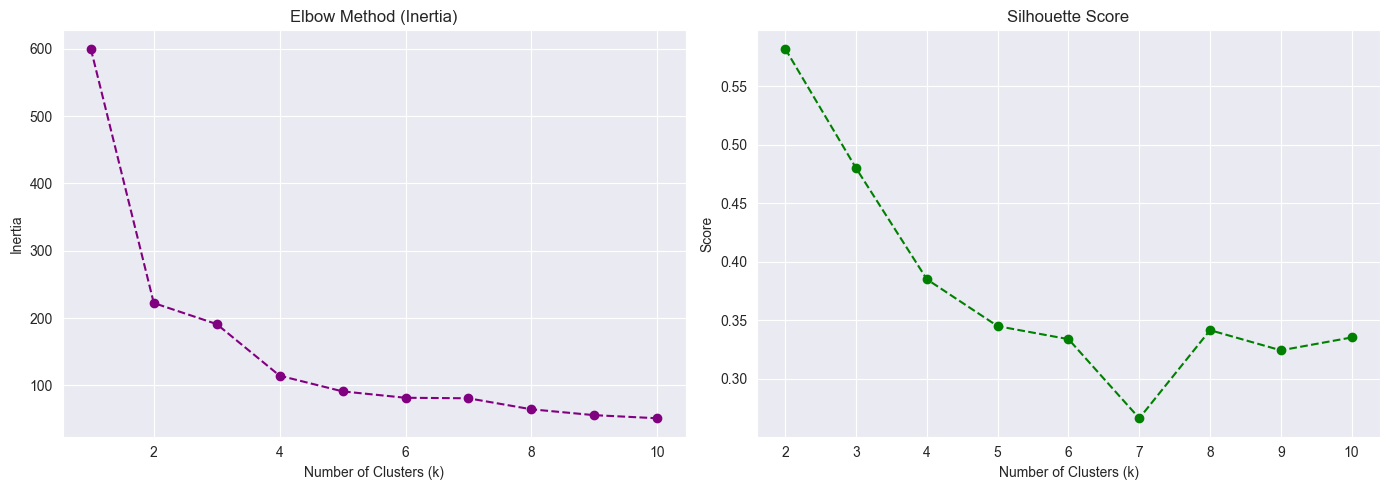

In [2]:
from matplotlib import pyplot as plt
from sklearn.metrics import silhouette_score
from src.models import KMeansWrapper

# Track metrics using KMeansWrapper class
inertias = []
silhouette_scores = []
K_range = range(1, 11)
K_range_sil = range(2, 11)

for k in K_range:
    # Instantiate our specific wrapper for each k
    kmeans_model = KMeansWrapper(n_clusters=k)

    # Fit the model and get labels
    labels = kmeans_model.fit_predict(X_scaled)

    # Access the scikit-learn model inside the wrapper to get inertia
    inertias.append(kmeans_model.model.inertia_)

    # Calculate Silhouette
    if k >= 2:
        sil_score = silhouette_score(X_scaled, labels)
        silhouette_scores.append(sil_score)

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(K_range, inertias, marker='o', linestyle='--', color='purple')
ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia')
ax[0].grid(True)

ax[1].plot(K_range_sil, silhouette_scores, marker='o', linestyle='--', color='g')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Score')
ax[1].grid(True)

plt.tight_layout()
plt.show()

#### Διαπιστώνουμε ότι: βέλτιστος αριθμός clusters = 3.
     - Στο διάγραμμα elbow παρατηρούμε οτι η inertia μειώνεται πολύ απότομα μέχρι n = 2 και στη συνέχεια πέφτει λίγο ακόμα μέχρι n = 3. Μετά απο
       αυτό το σημείο η inertia μειώνεται πολύ αργά.
     - Στο διάγραμμα silhouette παρατηρούμε μέγιστη τιμή το 2. Αυτό μας δείχνει οτι υπάρχουν 2 clusters που ξεχωρίζουν ξεκάθαρα.

##### Αρα είναι πολύ πιθανό να υπάρχουν 3 clusters αλλά 2 απο αυτά να αλληλοεπικαλύπτονται.
#### Τρέχουμε τον Agglomerative Clustering αλγόριθμο.
     Θα χρησιμοποιήσουμε hierarchical clustering με τη μέθοδο "ward" και θα υλοποιήσουμε Silhouette score για να διαλέξουμε αριθμό clusters.


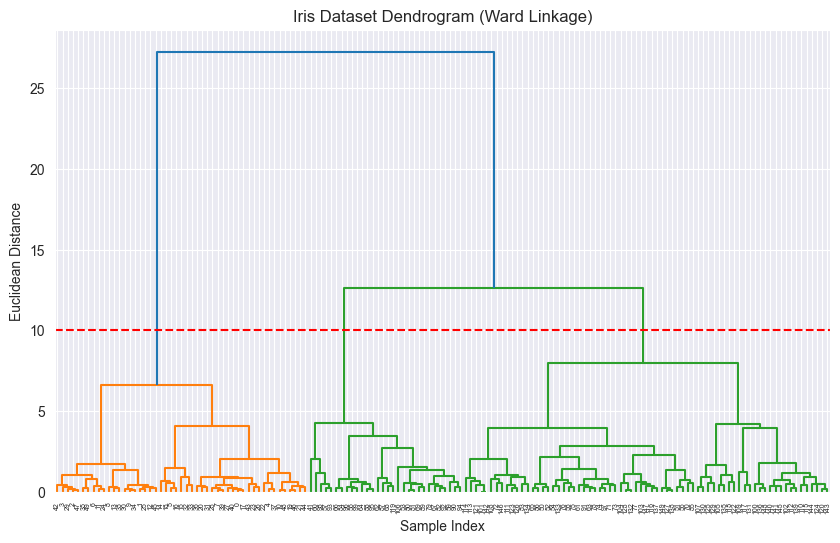

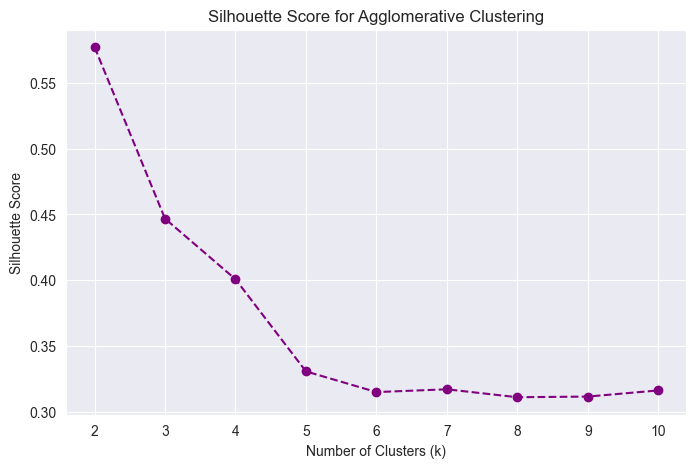

The highest Silhouette Score is at k = 2


In [3]:
from src.models import AgglomerativeWrapper
import scipy.cluster.hierarchy as shc
import numpy as np

# Plot the Dendrogram to visually inspect the hierarchy
plt.figure(figsize=(10, 6))
plt.title("Iris Dataset Dendrogram (Ward Linkage)")

# linkage function performs the hierarchical clustering for the plot
dend = shc.dendrogram(shc.linkage(X_scaled, method='ward'))
plt.xlabel("Sample Index")
plt.ylabel("Euclidean Distance")
plt.axhline(y=10, color='r', linestyle='--') # Example cut line
plt.show()

#  Find optimal k using Silhouette Score
agg_silhouette_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    # Instantiate the wrapper. Sklearn uses 'ward' linkage by default.
    agg_model = AgglomerativeWrapper(n_clusters=k)

    # Fit and get labels
    labels = agg_model.fit_predict(X_scaled)

    # Calculate score
    sil_score = silhouette_score(X_scaled, labels)
    agg_silhouette_scores.append(sil_score)

# Plot the Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(K_range_sil, agg_silhouette_scores, marker='o', linestyle='--', color='purple')
plt.title('Silhouette Score for Agglomerative Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range_sil)
plt.grid(True)
plt.show()

# Print the optimal k based on the highest score
optimal_k = K_range_sil[np.argmax(agg_silhouette_scores)]
print(f"The highest Silhouette Score is at k = {optimal_k}")

#### Παρατηρήσεις.
     - Στό δενδρόγραμμα παρατηρούμε πως για y = 10 παίρνουμε 3 clusters.
     - Στο διάγραμμα silhouette παρατηρούμε το υψηλότερο score  στο k = 2.
#### Τρέχουμε τον HDBSCAN αλγόριθμο ώστε να διακρίνουμε clusters με ποικίλες πυκνότητες.
     Σε αυτή την περίπτωση δεν χρειάζεται να θέσουμε αριθμό clusters (k) γιατί είναι κάτι που βρίσκει ο αλγόριμος, βασιζόμενος στην
     πυκνότητα των δεδομένων. Επίσης, ο συγκεριμένος αλγόριθμος διαχειρίζεται και τον θόρυβο (noise): σημεία που δεν ανήκουν σε πυκνή περιοχή
     μαρκάρονται ως -1 (θόρυβος).

HDBSCAN Tuning Results:
   min_cluster_size  n_clusters  n_noise  silhouette_score
0                 3           2        2          0.589917
1                 5           2        2          0.589917
2                10           2        2          0.589917
3                15           2        2          0.589917


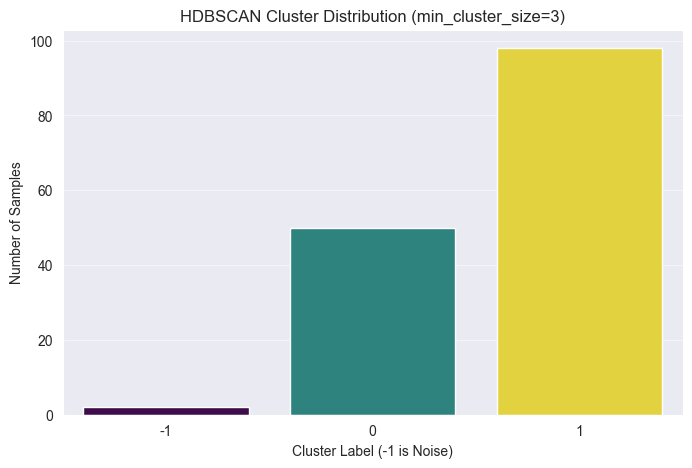

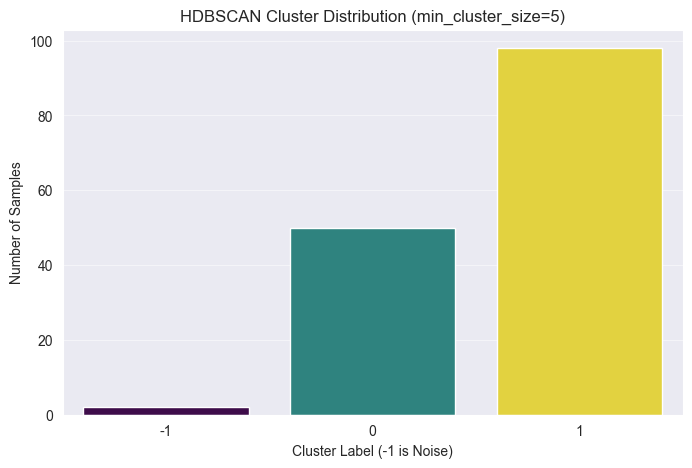

In [4]:
from src.models import HDBSCANWrapper
import seaborn as sns

# We will test different values for min_cluster_size
min_cluster_sizes = [3, 5, 10, 15]
results = []

for mcs in min_cluster_sizes:
    # Instantiate the HDBSCAN wrapper
    hdbscan_model = HDBSCANWrapper(min_cluster_size=mcs)
    hdbscan_model.model.set_params(copy=True)

    # Fit and get labels
    labels = hdbscan_model.fit_predict(X_scaled)

    # Filter out noise (-1) to calculate Silhouette score on valid clusters
    # (Silhouette score cannot handle single-cluster or all-noise results)
    valid_labels_mask = labels != -1
    n_clusters = len(set(labels[valid_labels_mask]))
    n_noise = list(labels).count(-1)

    if n_clusters >= 2:
        sil_score = silhouette_score(X_scaled[valid_labels_mask], labels[valid_labels_mask])
    else:
        sil_score = 0.0 # Not enough clusters formed

    results.append({
        'min_cluster_size': mcs,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'silhouette_score': sil_score
    })

# Convert results to a DataFrame for easy viewing
import pandas as pd
results_df = pd.DataFrame(results)
print("HDBSCAN Tuning Results:")
print(results_df)

# --- Visualize  ---

# min_cluster_size=3
size3_hdbscan = HDBSCANWrapper(min_cluster_size=3)
size3_hdbscan.model.set_params(copy=True)
best_labels = size3_hdbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
sns.countplot(x=best_labels, hue=best_labels, palette='viridis', legend=False)
plt.title('HDBSCAN Cluster Distribution (min_cluster_size=3)')
plt.xlabel('Cluster Label (-1 is Noise)')
plt.ylabel('Number of Samples')
plt.grid(axis='y', alpha=0.5)
plt.show()

# min_cluster_size=5
best_hdbscan = HDBSCANWrapper(min_cluster_size=5)
best_hdbscan.model.set_params(copy=True)
best_labels = best_hdbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
sns.countplot(x=best_labels, hue=best_labels, palette='viridis', legend=False)
plt.title('HDBSCAN Cluster Distribution (min_cluster_size=5)')
plt.xlabel('Cluster Label (-1 is Noise)')
plt.ylabel('Number of Samples')
plt.grid(axis='y', alpha=0.5)
plt.show()

#### Στα bar chart παρατηρούμε:
    - Παίρνουμε 2 cluster. Πιθανότατα υπάρχουν 2 cluster που ενώθηκαν σε 1 λόγω overlap.
    - Με -1 είναι σημειωμένα τα δεδομένα που χαρακτηρίστηκαν ως θόρυβος. Είναι λουλούδια που δεν μπόρεσαν να κατηγοριοποιηθούν σε κάποιο cluster.

#### Στη συνέχεια θα κάνουμε οπτικοποίηση των ευρημάτων μας.

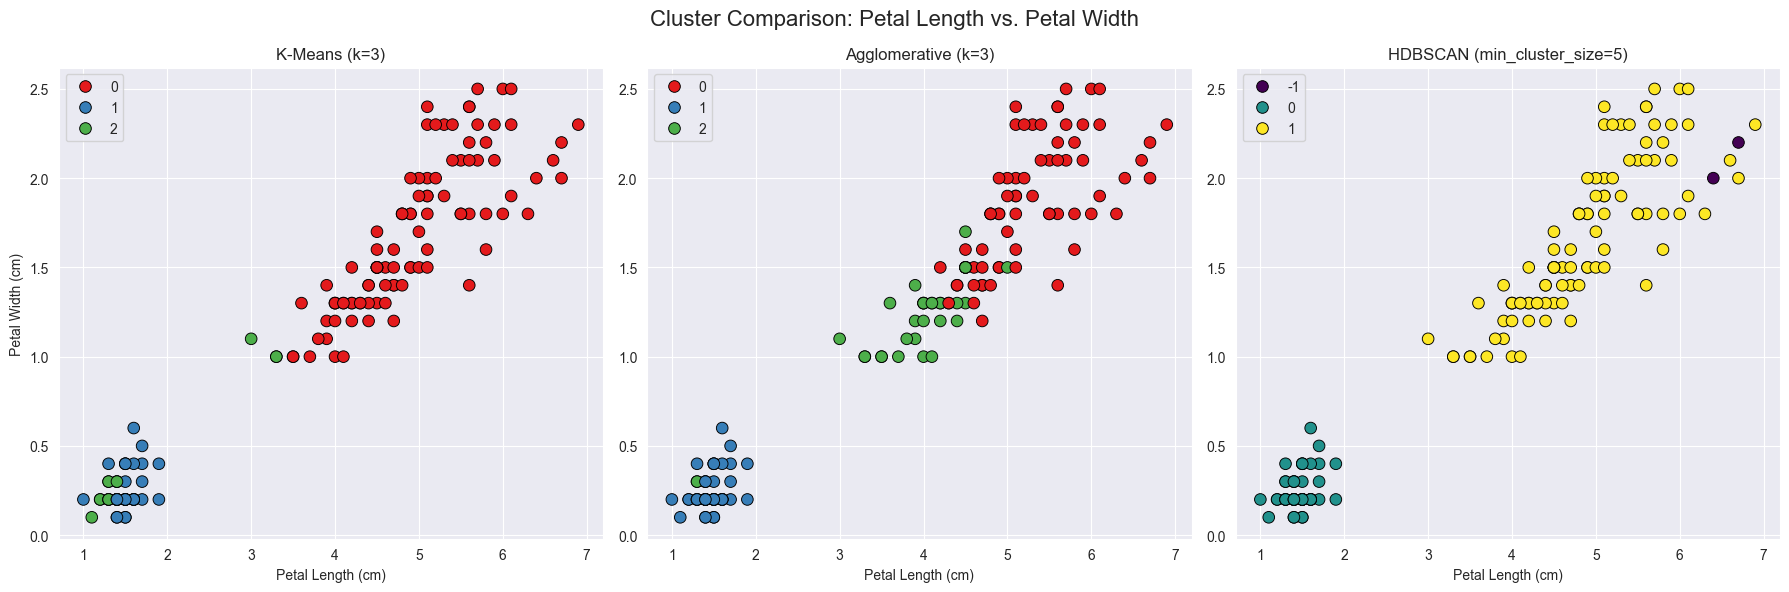

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from src.models import KMeansWrapper, AgglomerativeWrapper, HDBSCANWrapper

# 1. Instantiate the models with our chosen configurations
kmeans = KMeansWrapper(n_clusters=3)
agg = AgglomerativeWrapper(n_clusters=3)
hdbscan = HDBSCANWrapper(min_cluster_size=5)
hdbscan.model.set_params(copy=True)

# Fit models on the SCALED data
labels_kmeans = kmeans.fit_predict(X_scaled)
labels_agg = agg.fit_predict(X_scaled)
labels_hdbscan = hdbscan.fit_predict(X_scaled)

# We will use the original UNSCALED data for plotting so the axes show actual centimeters
petal_length = loader.features[:, 2]
petal_width = loader.features[:, 3]

# 2. Setup the plot grid (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.suptitle('Cluster Comparison: Petal Length vs. Petal Width', fontsize=16)

# --- Plot 1: K-Means ---
sns.scatterplot(x=petal_length, y=petal_width, hue=labels_kmeans,
                palette='Set1', ax=axes[0], s=70, edgecolor='k')
axes[0].set_title('K-Means (k=3)')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')

# --- Plot 2: Agglomerative ---
sns.scatterplot(x=petal_length, y=petal_width, hue=labels_agg,
                palette='Set1', ax=axes[1], s=70, edgecolor='k')
axes[1].set_title('Agglomerative (k=3)')
axes[1].set_xlabel('Petal Length (cm)')

# --- Plot 3: HDBSCAN ---
# Using a different palette to highlight the noise (-1)
sns.scatterplot(x=petal_length, y=petal_width, hue=labels_hdbscan,
                palette='viridis', ax=axes[2], s=70, edgecolor='k')
axes[2].set_title('HDBSCAN (min_cluster_size=5)')
axes[2].set_xlabel('Petal Length (cm)')

plt.tight_layout()
plt.show()

# Ευρήματα

#### K-Means:
        - Πως έτρεξε: σχημάτισε μια άκαμπτη γραμμή για να διαχωρίσει τα είδη versicolor και virginica δημιουργώντας 3 clusters.
        - Γιατι συνέβη αυτο: Ο K-Means ελαχιστοποιεί την διακύμανση και υποθέτει οτι τα clusters είναι σφαιρικά. Επηρεάζεται έντονα από
         την επικάλυψη μεταξύ των datapoints.
        - Συμπέρασμα: Δημιουργεί 3 cluster αλλά το όριο μεταξύ 2 εξ αυτών (virginica και versicolor) είναι τεχνητό. Δείγματα που
        πίπτουν ακριβώς πάνω στο όριο, χωρίζονται σε cluster απλά και μόνο γιατί είναι οριακά πιο κοντά (0,1 mm) στο κεντροειδές του.

#### Agglomerative:
        - Πως έτρεξε: παρόμοια με τον K-Means απο ότι βλέπουμε στο τελευταίο διάγραμμα, αλλά σχημάτισε μια ιεραρχία (δενδρόγραμμα).
        - Γιατι συνέβη αυτο: με τη χρήση του ward's linkage, συγχώνευσε τα δείγματα βήμα προς βήμα με βάση τις ελάχιστες αυξήσεις διακύμανσης.
        - Συμπέρασμα: αν και με μια γρήγορη ματιά μοιάζει με τον K-Means, κοιτώντας προσεκτικά το δεδρόγραμμα παίρνουμε επιπλέον πληροφόρηση.
         Βλέπουμε πόσο στενή συγγενική σχέση έχουν συγκεριμένα μεμονωμένα δείγματα, πρίν αυτά τελικά συγχωνευθούν σε μεγάλα clusters.

#### HDBSCAN:
        - Πως έτρεξε: διέκρινε μόνο 2 clusters και χαρακτήρισε αρκετά δείγματα που βρίσκονται ενδιάμεσα ως θόρυβο (-1).
        - Γιατι συνέβη αυτο: ο HDBSCAN αναζητά συνεχείς περιοχές υψηλής πυκνότητας. Επειδή τα versicolor και virginica επικαλύπτονται έντονα
          τα βλέπει ως ένα ποικιλόμορφο είδος και όχι σαν 2 ξεχωριστά.
        - Συμπέρασμα: μας δίνει την πιο ρεαλιστική απεικόνιση των αρχικών μετρήσεων. Αναγνωρίζει ότι με βάση ΜΟΝΟ το μέγεθος των cepal
          και petal, δέν μπορεί να γίνει αξιόπιστος διαχωρισμός των versicolor και virginica. Τα δείγματα που χαρακτήρισε ως θόρυβο είναι αυτά
          που είναι δυσδιάκριτα λόγω πολύ παρόμοιων χαρακτηριστικών.

# Τελικό συμπέρασμα
        - Αν ο στόχος μας είναι να διαχωρίσουμε τα δείγματα σε 3 κατηγορίες, ο K-Means θεωρείται το καταλληλότερο εργαλείο. Είναι πολύ γρήγορος
        ακόμη και σε μεγάλα dataset και δεν αφήνει κανένα δείγμα αταξινόμητο.
        - Aν ο στόχος μας είναι η ταξινομική έρευνα ή η μελέτη ταξινομικής καταγωγής, ο Agglomerative θεωρείται καταλληλότερος. Το δενδρόγραμμα
          λειτουργεί σχεδόν σαν οικογενειακό δένδρο. Μέσα απο την οπτικοποίηση των υπο-ειδών βοηθά στην κατανόηση των ιεραρχικών σχέσεων
          μεταξύ των γενετικών χαρακτηριστικών.
        - Aν ο στόχος μας είναι να μελετήσουμε τις φυσικές παραλλαγές και να εντοπίσουμε πιθανόν υβρίδια, ο HDBSCAN θεωρείται καταλληλότερος
          γιατί επισημαίνει τις αβέβαιες οριακές περιπτώσεις.